In [ ]:
# Importação das bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output
import gymnasium as gym

In [ ]:
# Dependencia para o ambiente do Lunar Lander
!pip install swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.9 MB/s eta 0:00:00


In [ ]:
# Dependencia para o ambiente do Lunar Lander
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 92.5 MB/s eta 0:00:00


In [ ]:
env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0, enable_wind=False, turbulence_power=1.0)

In [ ]:
# Tentativa de discretizar o espaço contínuo de estados
LIMITES = [
    (-1.5, 1.5),       # posição x
    (-0.5, 1.5),       # posição y
    (-1.5, 1.5),       # velocidade x
    (-1.5, 1.5),       # velocidade y
    (-np.pi, np.pi),   # ângulo
    (-2.5, 2.5)        # velocidade angular
]

# Número de faixas para cada variável de estado
NUM_FAIXAS = [10, 10, 8, 8, 10, 6]

# variável que vai receber os valores para cada faixa
# é uma lista de arrays
faixas = []

# cria a lista de arrays, zip desempacota LIMITES e NUM_FAIXAS como uma tupla
# [(-1.5, 1,5), 8], por ex.
for item in zip(LIMITES, NUM_FAIXAS):

    intervalo = item[0]
    n = item[1]

    limite_inferior = intervalo[0]
    limite_superior = intervalo[1]

    faixas.append(
        np.linspace(limite_inferior, limite_superior, n - 1)
    )

In [ ]:
# A ideia dessa função vai ser receber um estado contínuo e retornar uma tupla
# com o indice de faixas
def discretizar_estado(estado):

    estado_discreto = []

    # Variáveis contínuas
    for i in range(6):

        valor = estado[i]

        # Descobre qual faixa o valor pertence
        indice_faixa = np.digitize(valor, faixas[i])

        estado_discreto.append(indice_faixa)

    # Variáveis já discretas (0 ou 1)
    estado_discreto.append(int(estado[6]))
    estado_discreto.append(int(estado[7]))

    return tuple(estado_discreto)

In [ ]:
q_table = np.zeros(
    (
        NUM_FAIXAS[0],   # x
        NUM_FAIXAS[1],   # y
        NUM_FAIXAS[2],   # vx
        NUM_FAIXAS[3],   # vy
        NUM_FAIXAS[4],   # angulo
        NUM_FAIXAS[5],   # velocidade angular
        2,               # perna esquerda
        2,               # perna direita
        4                # ações
    ),
    dtype=np.float32
)

# não é mais uma matriz tradicional, porque vai ter 9 dimensões
q_table.shape

# a quantidade total de elementos vai ser: (10 x 10 x 8 x 8 x 10 x 6 x 2 x 2 x 4)
# 6 144 000

(10, 10, 8, 8, 10, 6, 2, 2, 4)

In [ ]:
# Q-Learning teste 1
alpha = 0.3
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.999
n_episodes = 10000
max_steps = 3000

recompensas = []

for episodio in range(n_episodes):
    estado_continuo, info = env.reset()
    estado = discretizar_estado(estado_continuo)
    recompensa_total = 0

    for passo in range(max_steps):

        # Escolhe uma ação usando a estratégia epsilon-greedy.
        if np.random.random() < epsilon:
            acao = env.action_space.sample()
        else:
            acao = int(np.argmax(q_table[estado]))

        # Executa a ação
        novo_estado_continuo, recompensa, terminated, truncated, info = env.step(acao)
        novo_estado = discretizar_estado(novo_estado_continuo)
        fim = terminated or truncated

        melhor_q_futuro = np.max(q_table[novo_estado])

        q_table[estado][acao] = q_table[estado][acao] + alpha * (recompensa + gamma * melhor_q_futuro - q_table[estado][acao])

        estado = novo_estado
        recompensa_total += recompensa

        if fim:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    recompensas.append(recompensa_total)

print("Treinamento concluído.")

Treinamento concluído.


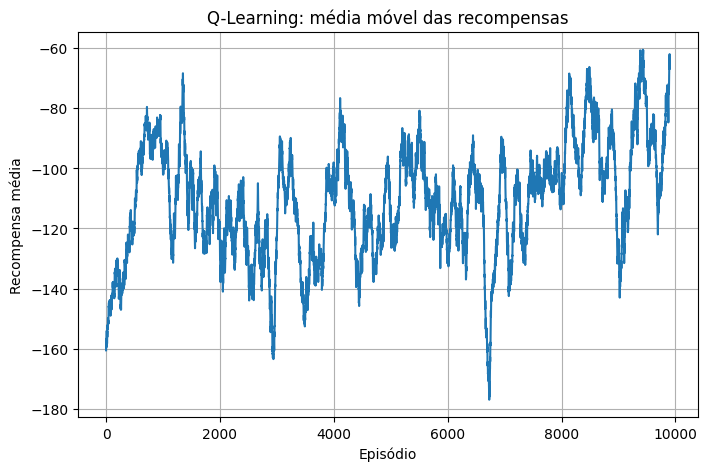

In [ ]:
# média movel
def media_movel(valores, janela=100):
    return np.convolve(valores, np.ones(janela)/janela, mode="valid")

plt.figure(figsize=(8, 5))
plt.plot(media_movel(recompensas, janela=100))
plt.title("Q-Learning: média móvel das recompensas")
plt.xlabel("Episódio")
plt.ylabel("Recompensa média")
plt.grid(True)
plt.show()

In [ ]:
# zerar a tabela q para teste 2
q_table = np.zeros_like(q_table)

In [ ]:
# Q-Learning teste 2
alpha = 0.2
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.999
n_episodes = 15000
max_steps = 4500

recompensas = []

for episodio in range(n_episodes):
    estado_continuo, info = env.reset()
    estado = discretizar_estado(estado_continuo)
    recompensa_total = 0

    for passo in range(max_steps):

        # Escolhe uma ação usando a estratégia epsilon-greedy.
        if np.random.random() < epsilon:
            acao = env.action_space.sample()
        else:
            acao = int(np.argmax(q_table[estado]))

        # Executa a ação
        novo_estado_continuo, recompensa, terminated, truncated, info = env.step(acao)
        novo_estado = discretizar_estado(novo_estado_continuo)
        fim = terminated or truncated

        melhor_q_futuro = np.max(q_table[novo_estado])

        q_table[estado][acao] = q_table[estado][acao] + alpha * (recompensa + gamma * melhor_q_futuro - q_table[estado][acao])

        estado = novo_estado
        recompensa_total += recompensa

        if fim:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    recompensas.append(recompensa_total)

print("Treinamento concluído.")

Treinamento concluído.


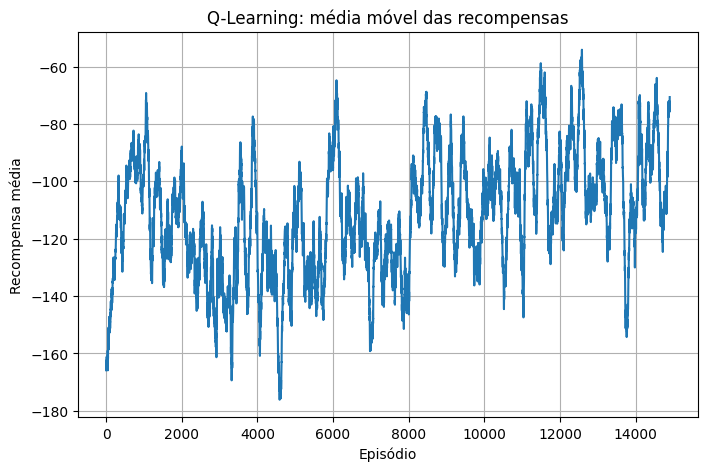

In [ ]:
# média movel
def media_movel(valores, janela=100):
    return np.convolve(valores, np.ones(janela)/janela, mode="valid")

plt.figure(figsize=(8, 5))
plt.plot(media_movel(recompensas, janela=100))
plt.title("Q-Learning: média móvel das recompensas")
plt.xlabel("Episódio")
plt.ylabel("Recompensa média")
plt.grid(True)
plt.show()

In [ ]:
# zerar a tabela q para teste 3
q_table = np.zeros_like(q_table)

In [ ]:
# Q-Learning teste 3
alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.999
n_episodes = 50000
max_steps = 500

recompensas = []

for episodio in range(n_episodes):
    estado_continuo, info = env.reset()
    estado = discretizar_estado(estado_continuo)
    recompensa_total = 0

    for passo in range(max_steps):

        # Escolhe uma ação usando a estratégia epsilon-greedy.
        if np.random.random() < epsilon:
            acao = env.action_space.sample()
        else:
            acao = int(np.argmax(q_table[estado]))

        # Executa a ação
        novo_estado_continuo, recompensa, terminated, truncated, info = env.step(acao)
        novo_estado = discretizar_estado(novo_estado_continuo)
        fim = terminated or truncated

        melhor_q_futuro = np.max(q_table[novo_estado])

        q_table[estado][acao] = q_table[estado][acao] + alpha * (recompensa + gamma * melhor_q_futuro - q_table[estado][acao])

        estado = novo_estado
        recompensa_total += recompensa

        if fim:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    recompensas.append(recompensa_total)

print("Treinamento concluído.")

Treinamento concluído.


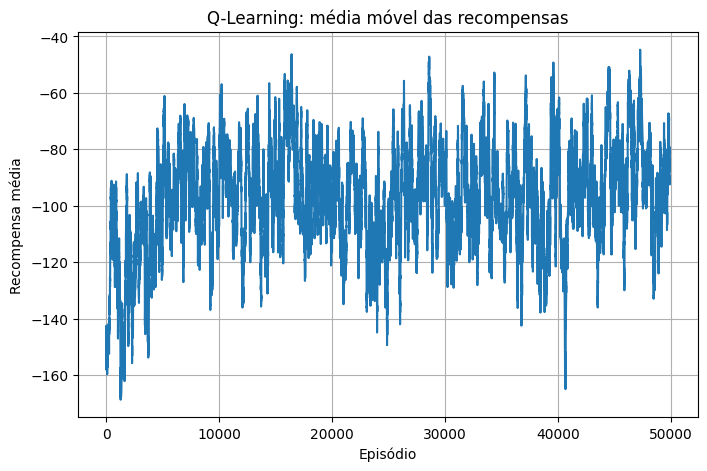

In [ ]:
# média movel
def media_movel(valores, janela=100):
    return np.convolve(valores, np.ones(janela)/janela, mode="valid")

plt.figure(figsize=(8, 5))
plt.plot(media_movel(recompensas, janela=100))
plt.title("Q-Learning: média móvel das recompensas")
plt.xlabel("Episódio")
plt.ylabel("Recompensa média")
plt.grid(True)
plt.show()